In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [12]:
df = pd.read_csv(r"C:\Users\Sophia\Downloads\retail_sales_dataset.csv")

In [18]:
df.sample(10, random_state=42)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
521,522,2023-01-01,CUST522,Male,46,Beauty,3,500,1500
737,738,2023-04-25,CUST738,Male,41,Clothing,2,50,100
740,741,2023-11-30,CUST741,Male,48,Clothing,1,300,300
660,661,2023-07-16,CUST661,Female,44,Clothing,4,25,100
411,412,2023-09-16,CUST412,Female,19,Electronics,4,500,2000
678,679,2023-01-11,CUST679,Female,18,Beauty,3,30,90
626,627,2023-10-14,CUST627,Male,57,Clothing,1,50,50
513,514,2023-03-01,CUST514,Female,18,Electronics,1,300,300
859,860,2023-01-09,CUST860,Male,63,Clothing,4,50,200
136,137,2023-11-18,CUST137,Male,46,Beauty,2,500,1000


In [ ]:
# 2. Report the exact number of rows, columns ,duplicated rows, and unique Transaction ID. State whether Transactino ID can safely act as a unique transaction key. 

In [19]:
rows = df.shape[0]
columns = df.shape[1]
duplicated_rows = df.duplicated().sum()
unique_transaction_ids = df["Transaction ID"].nunique()

print("Number of rows:", rows)
print("Number of columns:", columns)
print("Duplicated rows:", duplicated_rows)
print("Unique Transaction IDs:", unique_transaction_ids)

Number of rows: 1000
Number of columns: 9
Duplicated rows: 0
Unique Transaction IDs: 1000


In [20]:
if unique_transaction_ids == rows:
    print("Transaction ID can safely act as a unique transaction key.")
else:
    print("Transaction ID cannot safely act as a unique transaction key.")

Transaction ID can safely act as a unique transaction key.


In [ ]:
# The datset contains 1,000 rows and 9 columns. There are no duplicated rows. There are 1,000 unique Transaction IDs, which is equal to the total number of rows.
# Therefore, each transaction has a unique Transaction ID, and transaction ID can safely be used as a unique transaction key. 


In [ ]:
# 3. Build a compact audit table containing for evrey column: data type, number of missing values, percentage missing, and number of unique values. 

In [22]:
audit_table = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values":df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() /len(df)) *100,
    "Unique Values": df.nunique()
})

audit_table

,Data Type,Missing Values,Missing Percentage,Unique Values
Transaction ID,int64,0,0.0,1000
Date,object,0,0.0,345
Customer ID,object,0,0.0,1000
Gender,object,0,0.0,2
Age,int64,0,0.0,47
Product Category,object,0,0.0,3
Quantity,int64,0,0.0,4
Price per Unit,int64,0,0.0,5
Total Amount,int64,0,0.0,18


In [ ]:
# The audit table shows that the datset contains no missing values in any column. Transaction ID and Customer ID each have 1,000 unique values.
# Gender has 2 unique values and Product Category has 3.
# The Data column is currently stored as an object type, so it shuld be converted to datetime for time-based analysis. 

In [ ]:
# 4. Convert Date to datetime. Identify the earliest transaction date, latest transaction date, and the number of calendar days convered by the dataset. 

In [25]:
df["Date"] = pd.to_datetime(df["Date"])

earliest_date = df["Date"].min()
latest_date = df["Date"].max()
calendar_days = (latest_date - earliest_date).days + 1

print("Earliest transaction date:", earliest_date)
print("Latest transaction date:", latest_date)
print("Calendar days covered:", calendar_days)

Earliest transaction date: 2023-01-01 00:00:00
Latest transaction date: 2024-01-01 00:00:00
Calendar days covered: 366


In [ ]:
# The Date column was converted from object to datetime. The earliest transaction date is January 1, 2023, and the latest transaction date is January 1, 2024.
# Including both the start and end dates, the dataset covers 366 calendar days. 

In [26]:
df["Date"].dtype

dtype('<M8[ns]')

In [ ]:
# 5. Validate the logical relationship Total Amount = Quantity * Price pre Unit. Create a Boolean column that flags inconsistent rows and report how many violation exist. 

In [29]:
df["amount_inconsistent"] = ~np.isclose(
    df["Total Amount"],
    df["Quantity"] * df["Price per Unit"]
)

violations = df["amount_inconsistent"].sum()

print("Number of violations:", violations)

Number of violations: 0


In [ ]:
# A Boolean column named amount_inconsistent was created to identify transactions where Total Amount does not equal Quantity multiplied by Price per Unit.
# There were 0 violations, indicating that all transaction amounts are logically consistent 

In [31]:
df[["Quantity", "Price per Unit", "Total Amount", "amount_inconsistent"]].head()

,Quantity,Price per Unit,Total Amount,amount_inconsistent
0,3,50,150,False
1,2,500,1000,False
2,1,30,30,False
3,1,500,500,False
4,2,50,100,False


In [33]:
df["amount_inconsistent"] = (
    df["Total Amount"] != df["Quantity"] * df["Price per Unit"]
)

In [ ]:
# 6. Check for impossible values: Age below 10 or above 100, Quantity <=0, Price per Unit <=0, and Total Amount <=0. Return all suspicious rows in one filtered DataFrame 

In [36]:
suspicious_rows = df[
    (df["Age"] < 10) |
    (df["Age"] > 100) |
    (df["Quantity"] <= 0) |
    (df["Price per Unit"] <= 0) |
    (df["Total Amount"] <= 0)
]
suspicious_rows

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,amount_inconsistent


In [37]:
print("Number of suspicious rows:", len(suspicious_rows))

Number of suspicious rows: 0


In [ ]:
# The dataset was filtered for impossible or suspicious values, including ages below 10 or above 100, non-positive quantities, non-positive unit prices, and non-positive total amounts. No suspicious rows were found 

In [ ]:
# 7. Check whether a Customer ID is associated with more than one Gender value. If any are inconsistent, display the affected customer IDs and their distinct values. 

In [38]:
gender_check = df.groupby("Customer ID")["Gender"].nunique()
inconsistent_customers = gender_check[gender_check > 1]
inconsistent_customers

Series([], Name: Gender, dtype: int64)

In [39]:
if len(inconsistent_customers) > 0:
    result = df[
        df["Customer ID"].isin(inconsistent_customers.index)
    ].groupby("Customer ID")["Gender"].unique()

    print(result)
else:
    print("No inconsitsent Customer IDs found.")

No inconsitsent Customer IDs found.


In [ ]:
# Each Customer ID was checkd for the number of distinct Gender values associated with it. No Customer ID had more than one Gender value, so there were no gender inconsistencies in the dataset. 

In [ ]:
# 8. Compare memory usage before and after converting suitable low-cardinality text columns to hte category dtype. Report the percentage change in DatFrame memory usage.

In [ ]:
memory_before = df.memory_usage(deep=True).sum()

df["Gender"] = df["Gender"].astype("category")
df["Product Category"] = df["Product Category"].astype("category")

memory_after = df.memory_usage(deep=True).sum()

percentage_change = ((

In [7]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
# 8. Compare memory usage before and after converting suitable low-cardinality text columns to the category dtype. 
# Report the percentage change in DataFrame memory usage 

In [13]:
memory_before = df.memory_usage(deep=True).sum()

df["Gender"] = df["Gender"].astype("category")
df["Product Category"] = df["Product Category"].astype("category")

memory_after = df.memory_usage(deep=True).sum()

percentage_chage = ((memory_after - memory_before) / memory_before) * 100

print("Memory before:", memory_before)
print("Memory after:", memory_after)
print("Percentage change:", percentage_chage)

Memory before: 266565
Memory after: 157629
Percentage change: -40.866580383771314


In [ ]:
# The DataFrame's memory usage decreased by approximately 40.87% after converting low-cardinality text columns to the category dtype. 

In [ ]:
# 9. Rename all columns to lowercase snake_case, for example Product Category -> product_category and Price per Unit -> price_per_unit

In [14]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns)

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount'],
      dtype='object')


In [ ]:
# 10. Create year, month, month_name, quarter, day_of_week, and is_weekend column from the Date column

In [16]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["quarter"] = df["date"].dt.month_name()
df["quarter"] = df["date"].dt.quarter
df["day_of_week"] =df["date"].dt.day_name()
df["is_weekend"] = df["date"].dt.dayofweek

df[["date", "year", "month", "month_name", "quarter", "day_of_week", "is_weekend"]].head()

,date,year,month,month_name,quarter,day_of_week,is_weekend
0,2023-11-24,2023,11,November,4,Friday,4
1,2023-02-27,2023,2,February,1,Monday,0
2,2023-01-13,2023,1,January,1,Friday,4
3,2023-05-21,2023,5,May,2,Sunday,6
4,2023-05-06,2023,5,May,2,Saturday,5


In [ ]:
# 11. Create age_group using pd.cut() with sensible business-oriented bins such as Teen/Young Adult, Adult, Middle Age, and Senior.
# Clearly state the bin boundaires you chose. 

In [17]:
bins = [9, 24, 39, 59, 100]

labels = [
    "Teen/Young Adult",
    "Adult",
    "Middle Age",
    "Senior"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

df[["age", "age_group"]].head(10)

,age,age_group
0,34,Adult
1,26,Adult
2,50,Middle Age
3,37,Adult
4,30,Adult
5,45,Middle Age
6,46,Middle Age
7,30,Adult
8,63,Senior
9,52,Middle Age


In [18]:
df["age_group"].value_counts().sort_index()

age_group
Teen/Young Adult    149
Adult               293
Middle Age          443
Senior              115
Name: count, dtype: int64

In [ ]:
# 12. Create spend_level from Total Amount using pd.qcut() so transactions are divided into four approximately equal-sized spending groups. 
# Name the groups Low, Medium, High, and Premium 

In [19]:
# 12. Create spend_level using pd.qcut()

df["spend_level"] = pd.qcut(
    df["total_amount"],
    q=4,
    labels=["Low", "Medium", "High", "Premium"]
)

df[["total_amount", "spend_level"]].head(10)

,total_amount,spend_level
0,150,High
1,1000,Premium
2,30,Low
3,500,High
4,100,Medium
5,30,Low
6,50,Low
7,100,Medium
8,600,High
9,200,High


In [21]:
df["spend_level"].value_counts().sort_index()

spend_level
Low        262
Medium     238
High       298
Premium    202
Name: count, dtype: int64

In [ ]:
# 13. Create a unit_value_band column using Price per Unit with three categories. Do not choose arbitrary cutoffs: derive the boudnaries from the 33rd and 
# 67th percentiles. 

In [22]:
p33 = df["price_per_unit"].quantile(0.33)
p67 = df["price_per_unit"].quantile(0.67)

df["unit_value_band"] = pd.cut(
    df["price_per_unit"],
    bins=[-float("inf"), p33, p67, float("inf")],
    labels=["Low", "Medium", "High"]
)

print("33rd percentile:", p33)
print("67th percentile:", p67)

df[["price_per_unit", "unit_value_band"]].head(10)

33rd percentile: 30.0
67th percentile: 300.0


,price_per_unit,unit_value_band
0,50,Medium
1,500,High
2,30,Low
3,500,High
4,50,Medium
5,30,Low
6,25,Low
7,25,Low
8,300,Medium
9,50,Medium


In [23]:
# 14. Create customer-level features using groupby(): transaction_cost, total_spend, average_order_value, total_units, and average_unit_price.
# Store them in a new DataFrame with one row per customer. 

In [26]:
customer_summary = (
    df.groupby("customer_id", observed=True)
    .agg(
        transaction_count=("transaction_id", "count"),
        total_spend=("total_amount", "sum"),
        average_order_value=("total_amount", "mean"),
        total_units=("quantity", "sum"),
        average_unit_price=("price_per_unit", "mean")
    )
    .reset_index()
)

customer_summary.head()
    

,customer_id,transaction_count,total_spend,average_order_value,total_units,average_unit_price
0,CUST001,1,150,150.0,3,50.0
1,CUST002,1,1000,1000.0,2,500.0
2,CUST003,1,30,30.0,1,30.0
3,CUST004,1,500,500.0,1,500.0
4,CUST005,1,100,100.0,2,50.0


In [28]:
 # 15. Add each customer's lifetime total_spend back to the original transaction-level df using transform() or merge(). 
 # Then compute each transaction's percentage contribution to that customer's lifetime spend 

In [33]:
df["category_mean_amount"] = (
    df.groupby("product_category", observed=True)["total_amount"]
      .transform("mean")
)

In [ ]:
#16.  For each Product Category, calcualte the category mean Total Amount and create a new column amoutn_vs_category_mean = transaction Total Amoutn -category mean.

In [34]:
df["amount_vs_category_mean"] = (
    df["total_amount"] - df["category_mean_amount"]
)

In [35]:
df[[
    "product_category",
    "total_amount",
    "category_mean_amount",
    "amount_vs_category_mean"
]].head(10)

,product_category,total_amount,category_mean_amount,amount_vs_category_mean
0,Beauty,150,467.475570,-317.475570
1,Clothing,1000,443.247863,556.752137
2,Electronics,30,458.786550,-428.786550
3,Clothing,500,443.247863,56.752137
4,Beauty,100,467.475570,-367.475570
5,Beauty,30,467.475570,-437.475570
6,Clothing,50,443.247863,-393.247863
7,Electronics,100,458.786550,-358.786550
8,Electronics,600,458.786550,141.213450
9,Clothing,200,443.247863,-243.247863


In [ ]:
# 17. Within each Product Category, rank transactions from highest to lowest Total Amoutn using rank().
# Handle ties using an explicit ranking method of your choice 

In [37]:
df["category_rank"] = (
    df.groupby("product_category", observed=True)["total_amount"]
    .rank(method="dense", ascending=False)

)

df[[
    "product_category",
    "total_amount",
    "category_rank"
]].head(15)

,product_category,total_amount,category_rank
0,Beauty,150,10.0
1,Clothing,1000,4.0
2,Electronics,30,17.0
3,Clothing,500,7.0
4,Beauty,100,12.0
5,Beauty,30,17.0
6,Clothing,50,16.0
7,Electronics,100,12.0
8,Electronics,600,6.0
9,Clothing,200,9.0


In [ ]:
# 18. Delete Total Amount outliers separately inside each Product Category using the IQR rule. 
# Add an is_outlier column instead of deleting the rows. 

In [41]:
q1 = df.groupby("product_category", observed=True)["total_amount"].transform(
    lambda x: x.quantile(0.25)
)

q3 = df.groupby("product_category", observed=True)["total_amount"].transform(
    lambda x: x.quantile(0.75)
)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df["is_outlier"] = (
    (df["total_amount"] < lower_bound) |
    (df["total_amount"] > upper_bound) 
)

df[[
    "product_category",
    "total_amount",
    "is_outlier"
]].head(15)

,product_category,total_amount,is_outlier
0,Beauty,150,False
1,Clothing,1000,False
2,Electronics,30,False
3,Clothing,500,False
4,Beauty,100,False
5,Beauty,30,False
6,Clothing,50,False
7,Electronics,100,False
8,Electronics,600,False
9,Clothing,200,False


In [ ]:
# 19. Calculate total revenue, total units sold, average order value, median order value, and revenuep er unit for the whole dataset in one summary object 

In [45]:
# 19. Create one summary object for the whole dataset.

summary = pd.Series({
    "total_revenue": df["total_amount"].sum(),
    "total_units_sold": df["quantity"].sum(),
    "average_order_value": df["total_amount"].mean(),
    "median_order_value": df["total_amount"].median(),
    "revenue_per_unit": df["total_amount"].sum() / df["quantity"].sum()
})

summary

total_revenue          456000.000000
total_units_sold         2514.000000
average_order_value       456.000000
median_order_value        135.000000
revenue_per_unit          181.384248
dtype: float64

In [ ]:
# 20. Create a Product Category summary with revenue, units sold, number of transactions, average order value, average customer age, and number of 
# unique customers. Sort by revenue 

In [47]:
# 20. Create a Product summary and sort by revenue

category_summary = (
    df.groupby("product_category", observed=True)
    .agg(
        revenue=("total_amount", "sum"),
        units_sold=("quantity", "sum"),
        transaction_count=("transaction_id", "count"),
        average_order_value=("total_amount", "mean"),
        average_customer_age=("age", "mean"),
        unique_customers=("customer_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)

category_summary

,product_category,revenue,units_sold,transaction_count,average_order_value,average_customer_age,unique_customers
0,Electronics,156905,849,342,458.786550,41.736842,342
1,Clothing,155580,894,351,443.247863,41.948718,351
2,Beauty,143515,771,307,467.475570,40.371336,307


In [ ]:
# 21. For each Product Category, calculate its percentage contribution to total company revenue.
# Confirm that the percentages sum to approximately 100%. 

In [49]:
category_revenue = (
    df.groupby("product_category", observed=True)["total_amount"]
    .sum()
)

revenue_share = (
    category_revenue / df["total_amount"].sum() * 100
)

print(revenue_share)
print("Total percentage:", revenue_share.sum())

product_category
Beauty         31.472588
Clothing       34.118421
Electronics    34.408991
Name: total_amount, dtype: float64

Total percentage: 100.0


In [ ]:
# 22. Use groupby with multiple aggregations to compare Gender by transaction count, total revneue, average order value, median order value, and average quantity 

In [51]:
# Compare Gender using multiple aggregations. 

gender_summary = (
    df.groupby("gender", observed=True)
    .agg(
        transaction_count=("transaction_id", "count"),
        total_revenue=("total_amount", "sum"),
        average_order_value=("total_amount", "mean"),
        median_order_valu=("total_amount", "median"),
        average_quantity=("quantity", "mean")
    )
    .reset_index()
)

gender_summary

,gender,transaction_count,total_revenue,average_order_value,median_order_valu,average_quantity
0,Female,510,232840,456.549020,150.0,2.545098
1,Male,490,223160,455.428571,120.0,2.481633


In [ ]:
# 23. Build a crosstab of Gender vs Product Category showing transaction counts.
# Create a second normalized crosstab showing row percentages. 

In [53]:
# 23. Crosstab of Gender vs Product Category

gender_category_count = pd.crosstab(
    df["gender"],
    df["product_category"]
)

gender_category_pct = pd.crosstab(
    df["gender"],
    df["product_category"],
    normalize="index"
) * 100

print("Transaction Counts:")
print(gender_category_count)

print("\nRow Percentages:")
print(gender_category_pct)

Transaction Counts:


product_category,Beauty,Clothing,Electronics
gender,,,
Female,166,174,170
Male,141,177,172



Row Percentages:


product_category,Beauty,Clothing,Electronics
gender,,,
Female,32.54902,34.117647,33.333333
Male,28.77551,36.122449,35.102041


In [ ]:
# 24. Determine the most popular Product Category for each Gender by transaction count. 
# Solve this from grouped data rather than manually inspecting a table. 

In [59]:
# Find the most popular product category for each gender. 

gender_category_counts.groupby(
    "gender", observed=True
)["transaction_count"].idxmax()

most_popular_by_gender = (
    gender_category_counts.loc[
        gender_category_counts.groupby("gender")["transaction_count"].idxmax()
        ]
        .reset_index(drop=True)
)

most_popular_by_gender

C:\Users\Sophia\AppData\Local\Temp\ipykernel_20712\2181196080.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_category_counts.groupby("gender")["transaction_count"].idxmax()


,gender,product_category,transaction_count
0,Female,Clothing,174
1,Male,Clothing,177


In [60]:
# 25. Detremine the highest-revenue Product Category for evrey age_group.
# Return one winning category per age group together with its revenue

age_category_revenue = (
    df.groupby(["age_group", "product_category"], observed=True)["total_amount"]
    .sum()
    .reset_index(name="revenue")
)

top_category_by_age = (
    age_category_revenue.loc[
        age_category_revenue
        .groupby("age_group", observed=True)["revenue"]
        .idxmax()
    ]
    .reset_index(drop=True)
)

top_category_by_age

,age_group,product_category,revenue
0,Teen/Young Adult,Beauty,28905
1,Adult,Clothing,54330
2,Middle Age,Electronics,64635
3,Senior,Electronics,24065


In [ ]:
# 26. Find the top 10 customers by lifetime spend. For each, show transactino_count, toatl_spend, average_order_value, total_units, and favorite
# product Category by transaction count 

In [61]:
favorite_category = (
    df.groupby(["customer_id", "product_category"], observed=True)
    .size()
    .reset_index(name="category_transaction_count")
)

favorite_category = (
    favorite_category.loc[
        favorite_category
        .groupby("customer_id")["category_transaction_count"]
        .idxmax()
    ]
    [["customer_id", "product_category"]]
    .rename(columns={"product_category": "favorite_product_category"})
)

top_10_customers = (
    customer_summary
    .merge(favorite_category, on="customer_id", how="left")
    .sort_values("total_spend", ascending=False)
    .head(10)
)

top_10_customers

,customer_id,transaction_count,total_spend,average_order_value,total_units,average_unit_price,favorite_product_category
487,CUST487,1,2000,2000.0,4,500.0,Clothing
476,CUST476,1,2000,2000.0,4,500.0,Clothing
773,CUST773,1,2000,2000.0,4,500.0,Electronics
503,CUST503,1,2000,2000.0,4,500.0,Beauty
92,CUST093,1,2000,2000.0,4,500.0,Beauty
88,CUST089,1,2000,2000.0,4,500.0,Electronics
946,CUST946,1,2000,2000.0,4,500.0,Electronics
157,CUST157,1,2000,2000.0,4,500.0,Electronics
155,CUST155,1,2000,2000.0,4,500.0,Electronics
420,CUST420,1,2000,2000.0,4,500.0,Clothing


In [ ]:
# 27. Calculate the percentage of total revenue generated by the top 10 % of customers ranked by total_spend.
# Explain whether revenue appears concentrated among a relatively small customer group. 

In [62]:
# Calculate the percentage of total revenue generated by the top 10% of customers. 

customer_spend = (
    df.groupby("customer_id", observed=True)["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

top_10_percent_n = int(len(customer_spend) * 0.10)

top_10_percent_revenue = customer_spend.head(top_10_percent_n).sum()

total_revenue = customer_spend.sum()

top_10_percent_share = (
    top_10_percent_revenue / total_revenue * 100
)

print("Number of customers in top 10%:", top_10_percent_n)
print("Revenue from top 10% of customers:", top_10_percent_revenue)
print("Percentage of total revenue:", top_10_percent_share)





Number of customers in top 10%: 100
Revenue from top 10% of customers: 174200
Percentage of total revenue: 38.20175438596492


In [ ]:
# 28. Copmute monthly revenue, monthly transaction count, and monthly average order value. Then calculate month-over-month revenue growth
# percentage using pct_change()

In [63]:
monthly_summary = (
    df.groupby(df["date"].dt.to_period("M"))
    .agg(
        monthly_revenue=("total_amount", "sum"),
        transaction_count=("transaction_id", "count"),
        average_order_value=("total_amount", "mean")
    )
)

monthly_summary["revenue_growth_pct"] = (
    monthly_summary["monthly_revenue"].pct_change() * 100
)

monthly_summary

,monthly_revenue,transaction_count,average_order_value,revenue_growth_pct
date,,,,
2023-01,35450,76,466.447368,NaN
2023-02,44060,85,518.352941,24.287729
2023-03,28990,73,397.123288,-34.203359
2023-04,33870,86,393.837209,16.833391
2023-05,53150,105,506.190476,56.923531
2023-06,36715,77,476.818182,-30.921919
2023-07,35465,72,492.569444,-3.404603
2023-08,36960,94,393.191489,4.215424
2023-09,23620,65,363.384615,-36.093074


In [ ]:
# 29. Calculate a 7 day rolling average of daily revenue. Return the date with the largest positive difference between actual daily revenue and its 7 day 
# rolling average.

In [70]:
daily_revenue = (
    df.groupby("date")["total_amount"]
    .sum()
    .sort_index()
)

rolling_7day = daily_revenue.rolling(window=7).mean()

In [72]:
daily_revenue = (
    df.groupby("date")["total_amount"]
    .sum()
    .sort_index()
)

rolling_7days= daily_revenue.rolling(window=7).mean()

difference = daily_revenue - rolling_7day

largest_gap_date = difference.idxmax()

print("Date with largest positive difference:", largest_gap_date)
print("Actual revenue:", daily_revenue.loc[largest_gap_date])
print("7_day rolling average:", rolling_7day.loc[largest_gap_date])
print("Difference:", difference.loc[largest_gap_date])

Date with largest positive difference: 2023-05-23 00:00:00
Actual revenue: 8455
7_day rolling average: 2691.4285714285716
Difference: 5763.571428571428


In [ ]:
# 30. Build a pivot table with month_name as rows, Product Category as columns, and Total Amount as values using sum as the aggregation.
# Add row totals and column totals. 

In [76]:
monthly_category_pivot = pd.pivot_table(
    df,
    index="month_name",
    columns="product_category",
    values="total_amount",
    aggfunc="sum",
    margins=True,
    margins_name="Total",
    observed=True
)

month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December",
    "Total"
]

monthly_category_pivot = monthly_category_pivot.reindex(month_order)

monthly_category_pivot
 

product_category,Beauty,Clothing,Electronics,Total
month_name,,,,
January,13930,13125,9925,36980
February,14035,14560,15465,44060
March,10545,15065,3380,28990
April,11905,13940,8025,33870
May,12450,17455,23245,53150
June,10995,10170,15550,36715
July,16090,8250,11125,35465
August,9790,12455,14715,36960
September,6320,9975,7325,23620


In [ ]:
# 31. Find the category with the largest gap between its mean and median transaction value. Explain what a large mean-median gap may indicate about that
# category's distribution 

In [74]:
mean_median_gap = (
    df.groupby("product_category", observed=True)["total_amount"]
    .agg(["mean", "median"])
)

mean_median_gap["gap"] = (
    mean_median_gap["mean"] - mean_median_gap["median"]
).abs()

mean_median_gap = mean_median_gap.sort_values(
    "gap",
    ascending=False
)

mean_median_gap

,mean,median,gap
product_category,,,
Beauty,467.475570,120.0,347.475570
Clothing,443.247863,120.0,323.247863
Electronics,458.786550,150.0,308.786550


In [ ]:
# 32. Create a sorted horizontal bar chart of total revenue by Product Category. Annotate each bar with both its revenue value and percentage of overall revenue

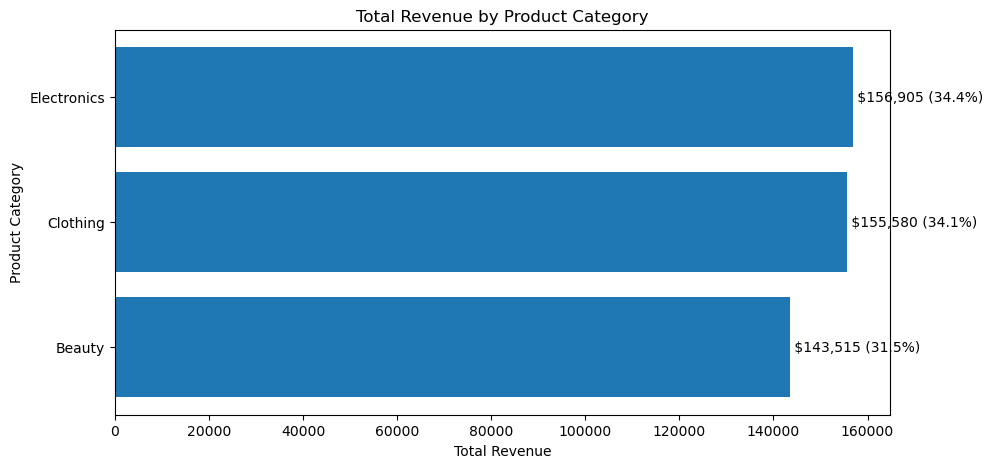

In [85]:
category_revenue = (
    df.groupby("product_category", observed=True)["total_amount"]
    .sum()
    .sort_values()
)

total_revenue = category_revenue.sum()

plt.figure(figsize=(10,5))

bars = plt.barh(
    category_revenue.index,
    category_revenue.values
)

for bar, revenue in zip(bars, category_revenue.values):
    pct = revenue / total_revenue * 100

    plt.text(
        revenue,
        bar.get_y() + bar.get_height() /2,
        f" ${revenue:,.0f} ({pct:.1f}%)", 
        va="center"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.show()

In [86]:
# 33. Plot monthly revenue as a line chart and overlay a second line for a 3-month rolling average. 
# Clearly distinguish the raw series from the smoothed trend. 

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, '2023-01'),
  Text(1, 0, '2023-02'),
  Text(2, 0, '2023-03'),
  Text(3, 0, '2023-04'),
  Text(4, 0, '2023-05'),
  Text(5, 0, '2023-06'),
  Text(6, 0, '2023-07'),
  Text(7, 0, '2023-08'),
  Text(8, 0, '2023-09'),
  Text(9, 0, '2023-10'),
  Text(10, 0, '2023-11'),
  Text(11, 0, '2023-12'),
  Text(12, 0, '2024-01')])

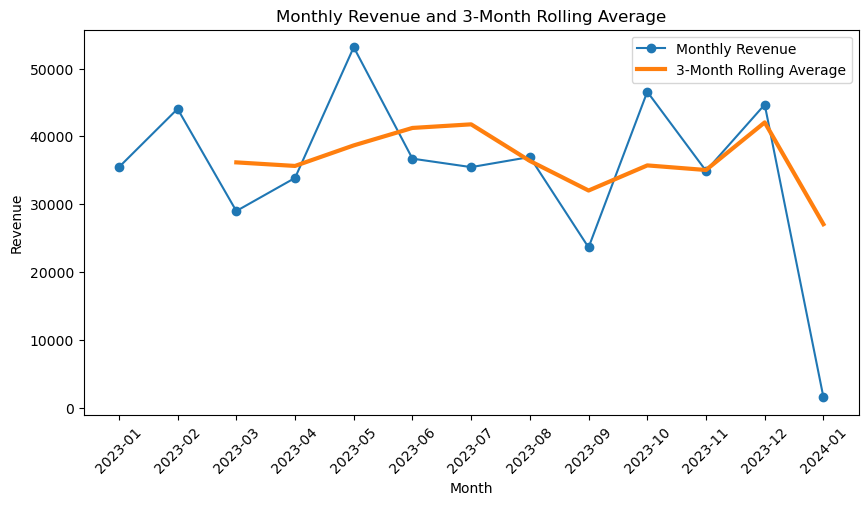

In [96]:
monthly_revenue = (
    df.groupby(df["date"].dt.to_period("M"))["total_amount"]
    .sum()
    .sort_index()
)

rolling_3month = monthly_revenue.rolling(window=3).mean()
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o",
    label="Monthly Revenue"
)

plt.plot(
    rolling_3month.index.astype(str),
    rolling_3month.values,
    linewidth=3,
    label="3-Month Rolling Average"
)

plt.title("Monthly Revenue and 3-Month Rolling Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)

In [ ]:
# 34. Create two separate histograms: one for Total Amount and one for log1p(Total Amount). Compare their shapes and explain why a log transformation
# can help with skewed data. 

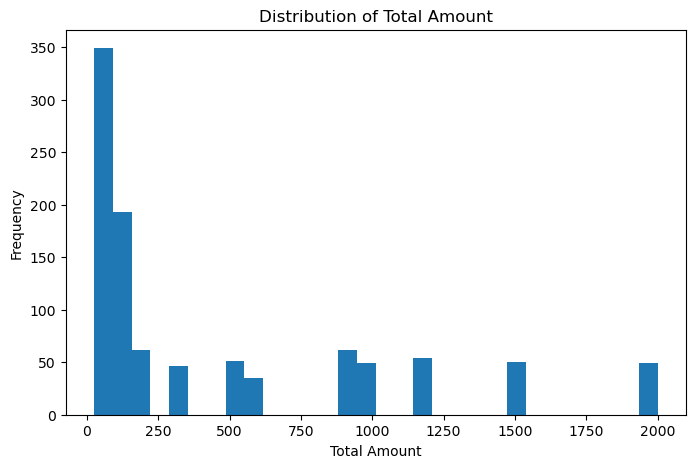

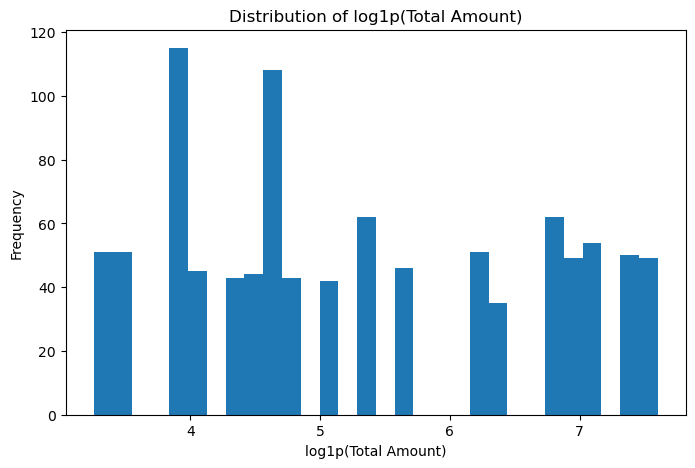

In [100]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["total_amount"],
    bins=30
)

plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")

plt.show()

log_total_amount = np.log1p(df["total_amount"])
plt.figure(figsize=(8,5))
plt.hist(
    log_total_amount,
    bins=30
)

plt.title("Distribution of log1p(Total Amount)")
plt.xlabel("log1p(Total Amount)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# The original Total Amount distribution is right-skewed,
# With many lower-value transactions and a smaller number of large transactions.
# After applying log1p, the distribution becomes less skewed because
# large values are compressed, making the overall pattern easier to analyze.

In [ ]:
# 35. Create a scatter plot of Quantiyt vs Total Amount. Encode Price per Unit as marker size. Explain why the relationship is not expected to foom a 
# single straight line. 

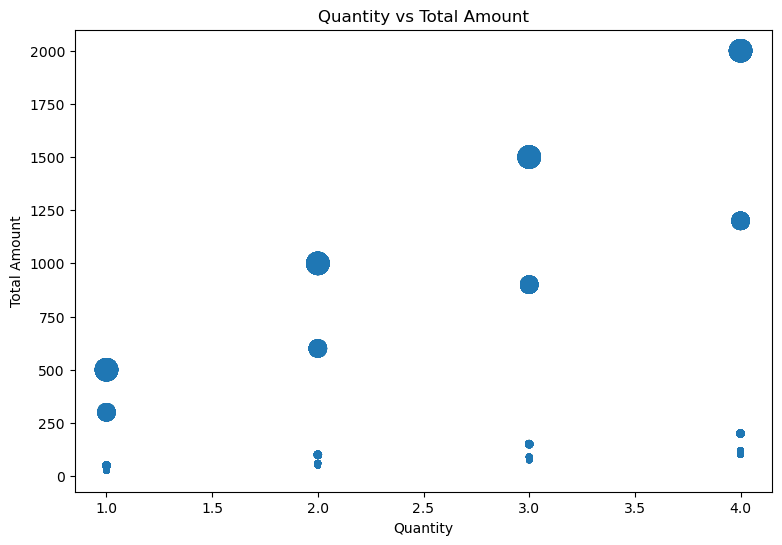

In [102]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["quantity"],
    df["total_amount"],
    s=df["price_per_unit"] / 2,
    alpha=0.6
)

plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")

plt.show()

In [ ]:
# Total Amount generally increases with Quantity, but the relationship does not form a single straight line because Price per Unit also varies.
# Transactions with the same Quantiyt can therefore have very different Total Amount values. 
# Total Amount tends to increase with Quantity, but the relationship is not linear because Price per Unit also varies. 

In [ ]:
# 36. Create a grouped bar chart comparing average order value across Product Category for Male and Female customers. Make sure categories align correctly on the x-axis. 

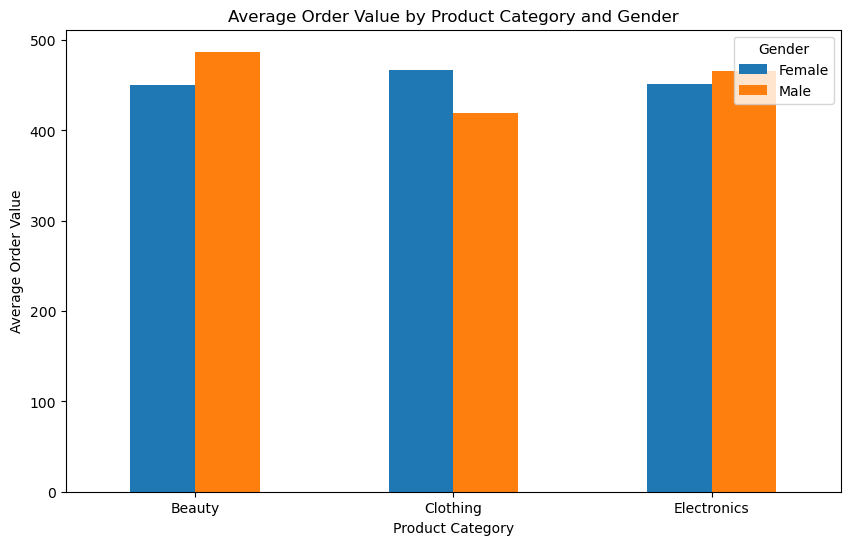

In [106]:
aov_by_gender = (
    df.groupby(
        ["product_category", "gender"],
        observed=True
    )["total_amount"]
    .mean()
    .unstack()
)

aov_by_gender.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Order Value by Product Category and Gender")
plt.xlabel("Product Category")
plt.ylabel("Average Order Value")
plt.xticks(rotation=0)
plt.legend(title="Gender")

plt.show()

In [ ]:
# 37. Create a stacked bar chart showing monthly revenue split by Product Category.
# Then idetnfiy whether the leading category changes over time. 

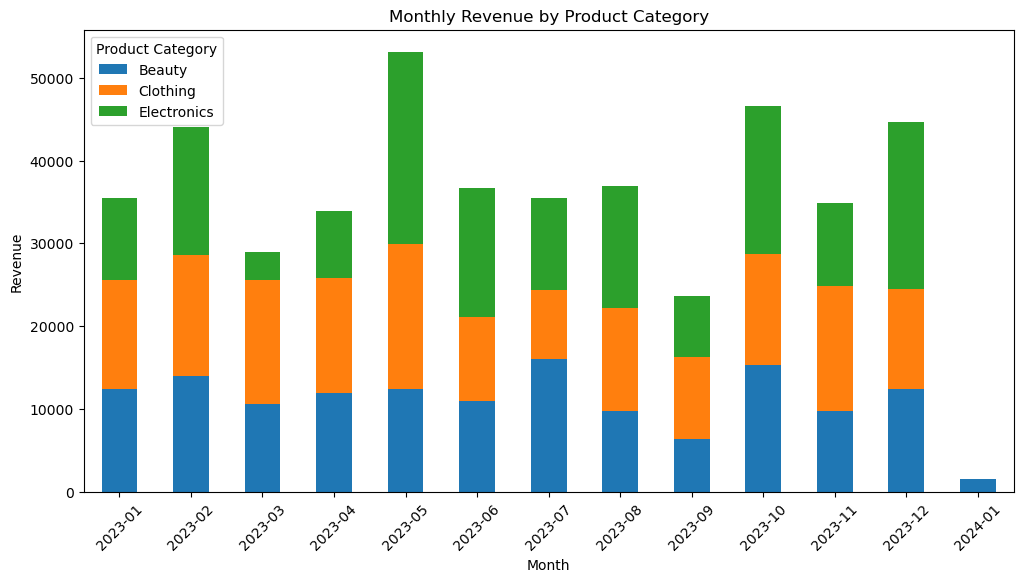

date
2023-01       Clothing
2023-02    Electronics
2023-03       Clothing
2023-04       Clothing
2023-05    Electronics
2023-06    Electronics
2023-07         Beauty
2023-08    Electronics
2023-09       Clothing
2023-10    Electronics
2023-11       Clothing
2023-12    Electronics
2024-01         Beauty
dtype: category
Categories (3, object): ['Beauty', 'Clothing', 'Electronics']

,transaction_id,date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,...,age_group,spend_level,unit_value_band,customer_total_spend,transaction_spend_pct,category_mean_amoutn,category_mean_amount,amount_vs_category_mean,category_rank,is_outlier
210,211,2024-01-01,CUST211,Male,42,Beauty,3,500,1500,2024,...,Middle Age,Premium,High,1500,100.0,467.47557,467.47557,1032.52443,2.0,False
649,650,2024-01-01,CUST650,Male,55,Electronics,1,30,30,2024,...,Middle Age,Low,Low,30,100.0,458.78655,458.78655,-428.78655,17.0,False


In [111]:
monthly_category_revenue = (
    df.groupby(
        [df["date"].dt.to_period("M"), "product_category"],
        observed=True
    )["total_amount"]
    .sum()
    .unstack(fill_value=0)
)

monthly_category_revenue.index = (
    monthly_category_revenue.index.astype(str)
)

monthly_category_revenue.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Monthly Revenue by Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend(title="Product Category")

plt.show()

monthly_leader = monthly_category_revenue.idxmax(axis=1)

print(monthly_leader)

df[df["date"].dt.to_period("M") == "2024-01"]

In [ ]:
# The leading product category changes over time.
# Electronics leads in several months, clothing leads in several others
# and Beauty leads in July 2032 and January 2024. 

In [ ]:
# 38. Create a box plot of Total Amount for each age_group. Add a horizontal ilne showing the overall median Total Amount and discuss which groups tend 
# to spend above or below it. 

C:\Users\Sophia\AppData\Local\Temp\ipykernel_20712\2060512134.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


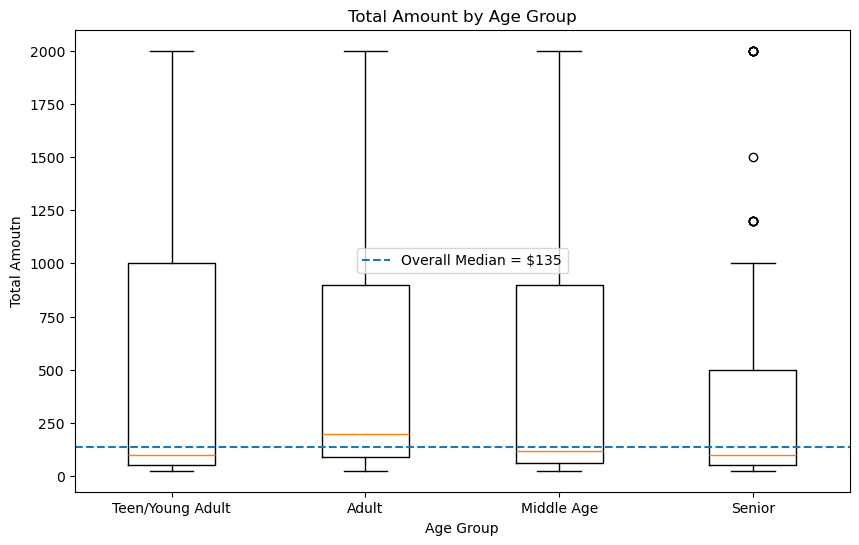

age_group
Teen/Young Adult    100.0
Adult               200.0
Middle Age          120.0
Senior              100.0
Name: total_amount, dtype: float64

Overall Median: 135.0


In [114]:
age_order = [
    "Teen/Young Adult",
    "Adult",
    "Middle Age",
    "Senior"
]

box_data = [
    df.loc[df["age_group"] == group, "total_amount"].dropna()
    for group in age_order
]

overall_median = df["total_amount"].median()

plt.figure(figsize=(10,6))

plt.boxplot(
    box_data,
    labels=age_order
)

plt.axhline(
    overall_median,
    linestyle="--",
    label=f"Overall Median = ${overall_median:,.0f}"
)

plt.title("Total Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Amoutn")
plt.legend()

plt.show()

age_group_median = (
    df.groupby("age_group", observed=True)["total_amount"]
      .median()
)

print(age_group_median)
print("Overall Median:", overall_median)

In [ ]:
# The overall median Total Amount is $135.
# Adult customers have the highest median transaction amount at $200, 
# which is above the overall median.
# Teen/Young Adult ($100), Middle Age ($120), and Senior($100)
# have median transaction amounts below the overall median.
# The senior groups also contain two high value outliers. 

In [ ]:
# 39. Create an ECDF-style plot manually with Matplotlib for Total Amount for at least two Product Categories. Use the curves to compare how quickly transaction
# values accumulate. 

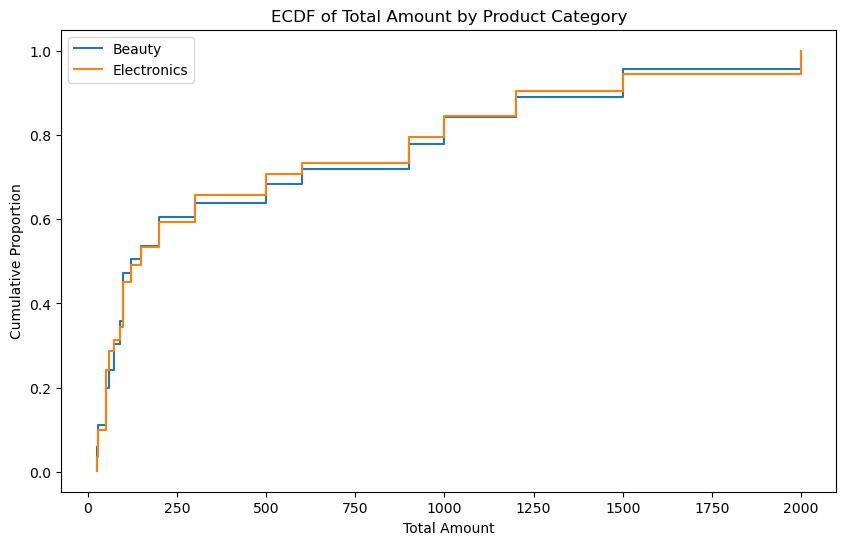

In [117]:
# EDCF- style plot for two Product Categories

beauty = np.sort(
    df.loc[df["product_category"] == "Beauty", "total_amount"].dropna()
)

electronics = np.sort(
    df.loc[df["product_category"] == "Electronics", "total_amount"].dropna()
)

beauty_ecdf = np.arange(1, len(beauty) + 1) / len(beauty)
electronics_ecdf = np.arange(1, len(electronics) + 1) /len(electronics)

plt.figure(figsize=(10,6))

plt.step(
    beauty,
    beauty_ecdf,
    where="post",
    label="Beauty"
)

plt.step(
    electronics,
    electronics_ecdf,
    where="post",
    label="Electronics"
)

plt.title("ECDF of Total Amount by Product Category")
plt.xlabel("Total Amount")
plt.ylabel("Cumulative Proportion")
plt.legend()

plt.show()

In [ ]:
# 40. Use sns.boxplot() to compare Total Amount across Product Category, with Gender as hue. Identify categories where the spending distributions differ most
# between genders. 

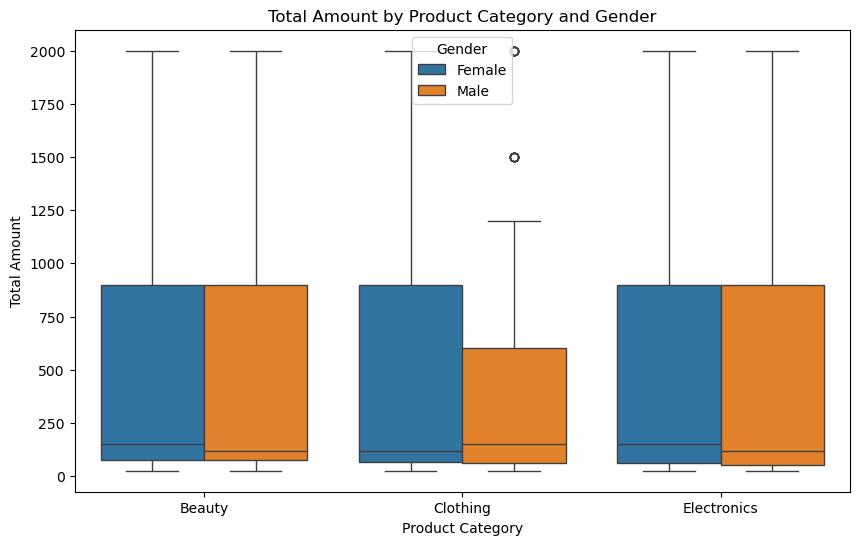

In [119]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="product_category",
    y="total_amount",
    hue="gender"
)

plt.title("Total Amount by Product Category and Gender")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.legend(title="Gender")

plt.show()

In [120]:
# Clothing shows the largest difference in spending distributions between genders.
# Female customers have a wider and generally higher middle range of transaction values,
# while Male customers hsow a lower IQR with several high-value outliers.
# Beauty and Electronics show more similar spending distributions between genders. 

In [ ]:
# 41. Use sns.violinplot() to compare Age distributions by Product Category. Detremine whic hcategories appear to attract younger or older customers 

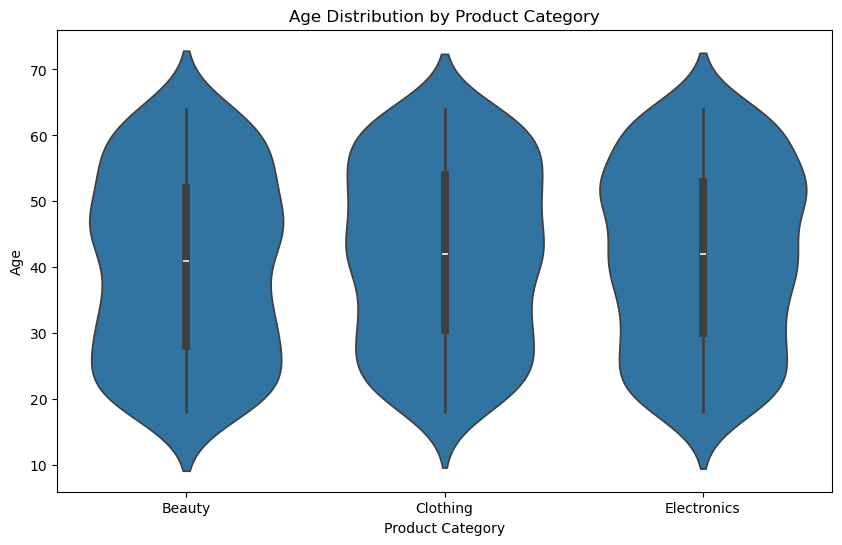

In [123]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="product_category",
    y="age"
)

plt.title("Age Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Age")

plt.show()

In [ ]:
# Age distributions are fairly similar across Beauty, Clothing, and Electronics.
# The median ages are all aroudn the early 40s, and no category clearly attracts
# substantially younger or older customers. 

In [ ]:
# 42. Create a Seaborn heatmap from a pivot table of age_group x Product Category where values are total revenue. Annotate the cells and identify the strongest
# age-category combinations. 

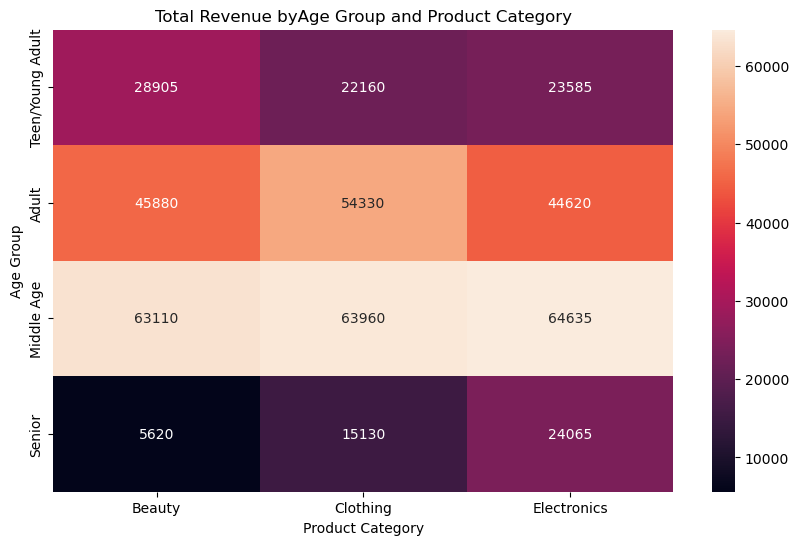

Strongest combination: ('Middle Age', 'Electronics')
Revenue: 64635


In [127]:
age_category_pivot = pd.pivot_table(
    df,
    index="age_group",
    columns="product_category",
    values="total_amount",
    aggfunc="sum",
    observed=True
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    age_category_pivot,
    annot=True,
    fmt=".0f"
)

plt.title("Total Revenue byAge Group and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Age Group")

plt.show()

strongest_combo = age_category_pivot.stack().idxmax()
strongest_revenue = age_category_pivot.stack().max()

print("Strongest combination:", strongest_combo)
print("Revenue:", strongest_revenue)

In [ ]:
# Middle Age customers generate the strongest revenue across all three product categories, with Electronics being the highest combination at $64,635. 
# Senior customers contribute the least overall. 

In [ ]:
# 43. Build a correlation heatmap for the numerical variables plus engineered features that are meaningfully numeric. 
# Before interpreting it, explain why Total Amount will naturally be strongly related to Quantiyt and Price per Unit. 

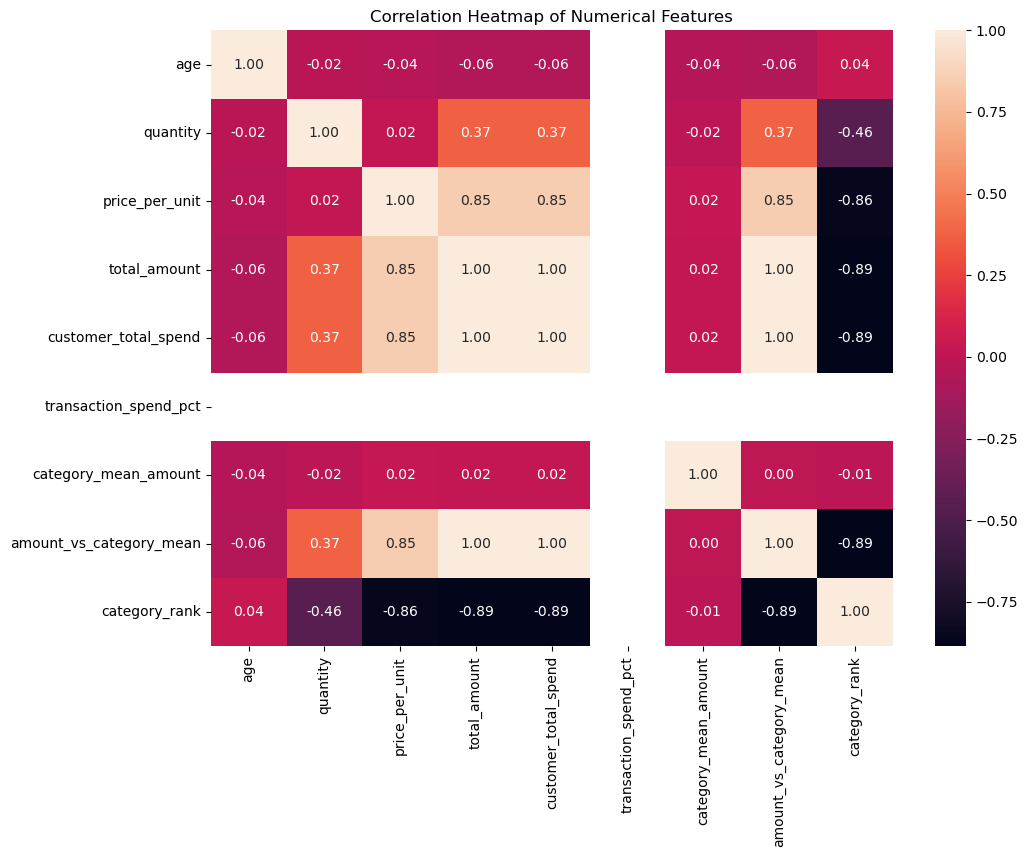

In [128]:
numeric_cols = [
    "age",
    "quantity",
    "price_per_unit",
    "total_amount",
    "customer_total_spend",
    "transaction_spend_pct",
    "category_mean_amount",
    "amount_vs_category_mean",
    "category_rank"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [129]:
df["transaction_spend_pct"].value_counts()

transaction_spend_pct
100.0    1000
Name: count, dtype: int64

In [ ]:
# Total Amount is naturally related to Quantity and Price per Unit
# because Total Amount is calcualted as Quantiyt x Price per Unit.
# Price per Unit shows a strong positvie correlation with Total Amount(0.85),
# while Quantity shows a moderate positvie correlation (0.37).
# Age has almost no linear relationship with Total Amount(-0.06).
# Category Rank has a strongest negative correlation with Total Amount (-0.89)
# because higher transaction amounts receive lower rank numbers. 

In [ ]:
# 44. Use sns.regplot() to study the relationship between Age and Total Amount. Then compute the Pearson and Spearman correlations and compare the 
# conclusions from the plot and the two  coefficients. 

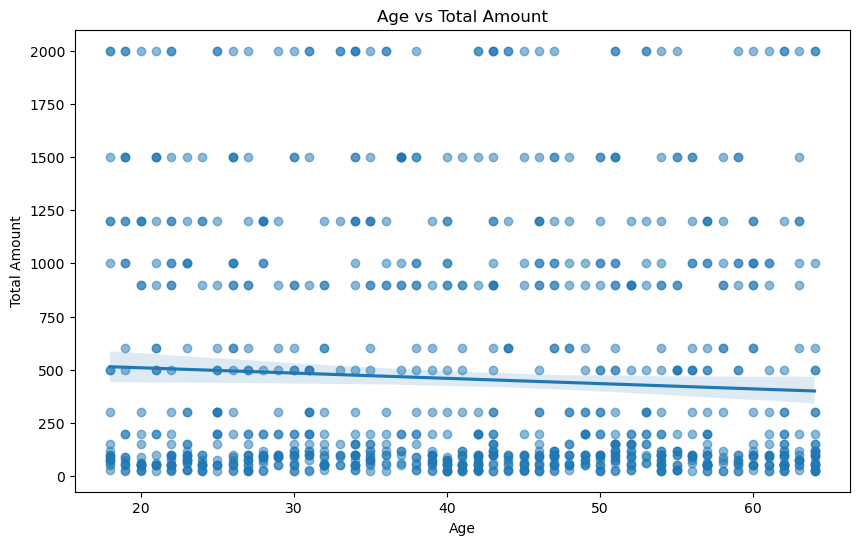

Pearson correlation: -0.060568023883045684
Spearman correlation: -0.037864028718041294


In [134]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="age",
    y="total_amount",
    scatter_kws={"alpha": 0.5}
)

plt.title("Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")

plt.show()

pearson_corr = df["age"].corr(
    df["total_amount"],
    method="pearson"
)

spearman_corr = df["age"].corr(
    df["total_amount"],
    method="spearman"
)

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

In [ ]:
# Both Pearson(-0.06) and Spearman (-0.04) correlations are close to zero.
# The regression line is also nearly flat.
# Therefore, Age has little to no meaningful relationship with Total Amount. 

In [135]:
# 45. Create a FacetGrid or catplot that compares Quantity distributions across Product Category separately for each Gender. 
# Write two observations based on the facets. 

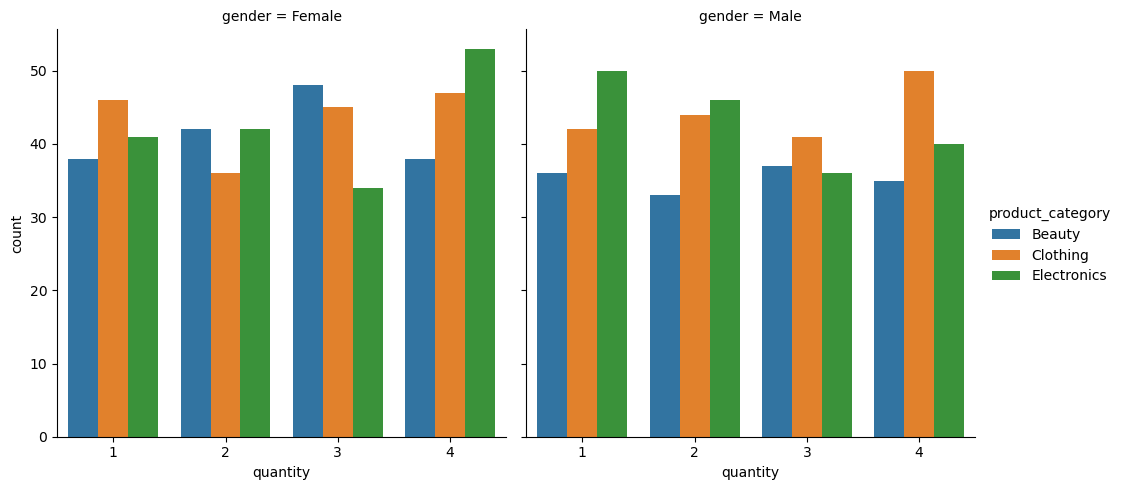

In [136]:
sns.catplot(
    data=df,
    x="quantity",
    hue="product_category",
    col="gender",
    kind="count",
    height=5,
    aspect=1
)

plt.show()

In [ ]:
# observation 1: 
# Female customers show the highest Electronics count at Quantity = 4,
# while Beauty is most common at Quantity = 3.

# Observation 2:
# Male customers show the highest Clothing count at Quantity = 4,
# while Electronics is most common at Quantity = 1

In [ ]:
# 46. Use sns.scatterplot() with Age on x, Total Amount on y, Product Category as hue, and Quantity as size. Identify any clusters or extreme transactions
# that deserve further investigation. 

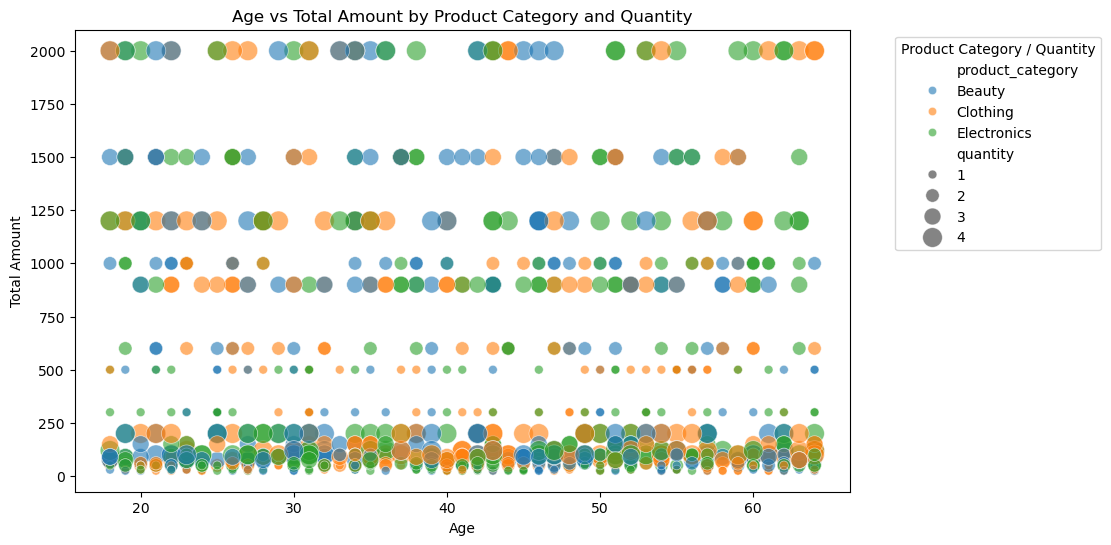

In [137]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="age",
    y="total_amount",
    hue="product_category",
    size="quantity",
    sizes=(40, 200),
    alpha=0.6
)

plt.title("Age vs Total Amount by Product Category and Quantity")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.legend(
    title="Product Category / Quantity",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()
    

In [ ]:
# Most transactions cluster at relatively low Total Amount values,
# especially below about $250.

# High-value transactions around $1,200, $1,500, and $2,000
# appear across multiple ages and product categories and may deserve
# further investigation

#There is no clear aged- based or product-categroy cluster,
# which is inconsitent with the weak relationship between Age and Total Amount

In [ ]:
# 47. Create a customer segmentation using two variables: purchase frequency and total spend. Divide each variable into Low/High based on its median, producing
# four segments. Report the size and revenue contribution of each segment. 

In [145]:
frequency_median = customer_summary["transaction_count"].median()
spend_median = customer_summary["total_spend"].median()

print("Frequency Median:", frequency_median)
print("Spend Median:", spend_median)

customer_summary["frequency_level"] = np.where(
    customer_summary["transaction_count"] > frequency_median,
    "High",
    "Low"
)

customer_summary["spend_level_segment"] = np.where(
    customer_summary["total_spend"] > spend_median,
    "High",
    "Low"
)

customer_summary["segment"] = (
    customer_summary["frequency_level"]
    + "Frequency /"
    + customer_summary["spend_level_segment"]
    + "Spend"
)

segment_summary = (
    customer_summary.groupby("segment")
    .agg(
        customer_coutn=("customer_id", "count"),
        total_revenue=("total_spend", "sum")
    )
)

segment_summary["revenue_share_pct"] = (
    segment_summary["total_revenue"]
    / segment_summary["total_revenue"].sum()
    * 100
)

segment_summary

Frequency Median: 1.0
Spend Median: 135.0


,customer_coutn,total_revenue,revenue_share_pct
segment,,,
LowFrequency /HighSpend,500,421600,92.45614
LowFrequency /LowSpend,500,34400,7.54386


In [146]:
customer_summary["transaction_count"].value_counts()

transaction_count
1    1000
Name: count, dtype: int64

In [147]:
# All customers have only one transaction, so purchase frequency
# cannot meaningfully separate customers into Low and High groups.
# Therfeore, only two segments appear based on spending level.
# The 500 High-Spend customers contribute about 92.46% of total revenue,
# while the 500 Low-Spend customers contribute only about 7.54%

In [ ]:
# 48. For each Product Category, compute an index =c ategory revenue share / category transaction share. Interpret values greater than 1 and less than 1, 
# and identify the category with the highest index 

In [150]:
# Revenue Share / Transaction Share Index

category_stats = (
    df.groupby("product_category", observed=True)
    .agg(
        revenue=("total_amount", "sum"),
        transactions=("transaction_id", "count")
    )
)

category_stats["revenue_share"] = (
    category_stats["revenue"]
    / category_stats["revenue"].sum()
)

category_stats["transaction_share"] = (
    category_stats["transactions"]
    / category_stats["transactions"].sum()
)

category_stats["index"] = (
    category_stats["revenue_share"]
    / category_stats["transaction_share"]
)

highest_index_category = category_stats["index"].idxmax()

print(category_stats)
print("Highest index category:", highest_index_category)

,revenue,transactions,revenue_share,transaction_share,index
product_category,,,,,
Beauty,143515,307,0.314726,0.307,1.025166
Clothing,155580,351,0.341184,0.351,0.972035
Electronics,156905,342,0.344090,0.342,1.006111


Highest index category: Beauty


In [ ]:
# Beauty has the highest index at approximately 1.03
# This means Beauty contributes slightly more revenue relative to its share of transactions.
# Electronics also has an index slightly above 1, while clothing is below 1.
# Clothing has a relatively larger transaction share than revenue share. 

In [ ]:
# 49. Define a repeat customer as a customer with more than one transaction. Compare repeat vs one-time customers by count, total revenue, average order value,
# and average quantity. Visualize at least two of these comparisons. 

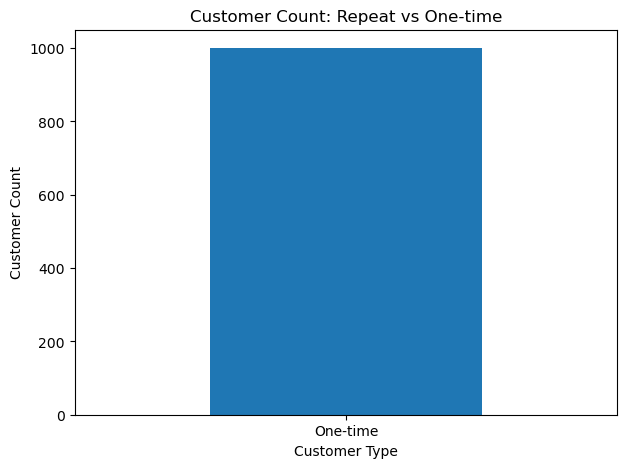

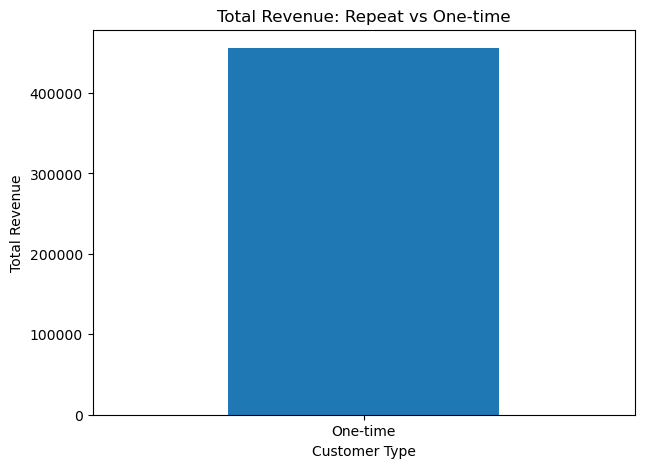

In [159]:
customer_transaction_count = (
    df.groupby("customer_id")["transaction_id"]
      .count()
)

df["customer_transaction_count"] = (
    df["customer_id"].map(customer_transaction_count)
)

df["customer_type"] = np.where(
    df["customer_transaction_count"] > 1,
    "Repeat",
    "One-time"
)

customer_type_summary = (
    df.groupby("customer_type")
    .agg(
        customer_count=("customer_id", "nunique"),
        total_revenue=("total_amount", "sum"),
        average_order_value=("total_amount", "mean"),
        average_quantity=("quantity", "mean")
    )
)

customer_type_summary

customer_type_summary["customer_count"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Customer Count: Repeat vs One-time")
plt.xlabel("Customer Type")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.show()

customer_type_summary["total_revenue"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Total Revenue: Repeat vs One-time")
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# All 1,000 customers are one-time customers.
# There are no repeat customers in the dataset.
# Therefore, all revenue comes from one-time customers,
# and a meaningful comparison between repeat and one-time customers is not possible. 

In [160]:
customer_type_summary

,customer_count,total_revenue,average_order_value,average_quantity
customer_type,,,,
One-time,1000,456000,456.0,2.514


In [161]:
# 50. Write a short business analysis containing exactly five evidence-based findings from the dataset. At least one finding must involve time 
# one customer behavior, one proudct category, one demographic comparison, and one unusual pattern or outlier. Every finding must cite a calculation 
# or visaulization you created earlier. 

In [170]:
# 50. Final Business Analysis

# 1. Time finding
monthly_revenue = (
    df.groupby(df["date"].dt.to_period("M"))["total_amount"]
      .sum()
)

best_month = monthly_revenue.idxmax()
best_month_revenue = monthly_revenue.max()

# 2. Customer behavior finding
customer_spend = (
    df.groupby("customer_id", observed=True)["total_amount"]
      .sum()
)

spend_median = customer_spend.median()


high_spend_revenue = customer_spend[
    customer_spend > spend_median
].sum()


high_spend_share = (
    high_spend_revenue
    / customer_spend.sum()
    *100
)

print("Spend Median:", spend_median)
print("High-spend customer revenue share:", high_spend_share)

# 3. Product category finding
category_revenue = (
    df.groupby("product_category", observed=True)["total_amount"]
      .sum()
)

top_category = category_revenue.idxmax()
top_category_revenue = category_revenue.max()

# 4. Demographic findign
age_medians = (
    df.groupby("age_group", observed=True)["total_amount"]
      .median()
)

top_age_group = age_medians.idxmax()
top_age_median = age_medians.max()
overall_median = df["total_amount"].median()

# 5. Unusual / Outlier finding
max_transaction = df["total_amount"].max()
max_transaction_count = (
    df["total_amount"] == max_transaction
).sum()

print("1. Best month:", best_month, "-", best_month_revenue)

print(
    "2. High-spend customer revenue share:",
    round(high_spend_share, 2), "%"
)

print(
    "3. Top product category:",
    top_category, 
    "-",
    top_category_revenue
)

print(
    "4. Highest median age group:",
    top_age_group,
    "-",
    top_age_median,
    "| Overall median:", 
    overall_median
)

print(
    "5. Maximum transaction:",
    max_transaction,
    "| Number of transaction:",
    max_transaction_count
)

Spend Median: 135.0
High-spend customer revenue share: 92.45614035087719
1. Best month: 2023-05 - 53150
2. High-spend customer revenue share: 92.46 %
3. Top product category: Electronics - 156905
4. Highest median age group: Adult - 200.0 | Overall median: 135.0
5. Maximum transaction: 2000 | Number of transaction: 49


In [171]:
# 50. Final Business Analysis

# 1. Time
# May 2023 generated the highest monthly revenue at $53,150.
# This is supported by the monthly revenue ahalysis from Q28/Q37.

# 2. Customer behavior
# Customer spending above the median of $135 generated approximately 92.46 % of total revenue, showing that revenue is highly concentrated
# among higher-spending customers(Q47).

# 3. Product Category
# Electronics generated the highest total revenue at $156,905, 
# making it the top-performing product category by revenue(Q20/Q32).

# 4. Demographic Comparison
# Adult customers had the highest median transaction amount at $200,
# compared with the overall median of $135(Q38).

# 5. Unusual Pattern
# The maximum transaction amount was $2,000, and this maximum value
# occured in 49 transactions, representing a notable high-value pattern that may deserve further investigation(Q46). 